<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4p/blob/main/51_rescorla_wagner.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(stan-rescorla-wagner-notebook)=
# Inferenza sull'apprendimento associativo con Stan

L'apprendimento associativo è un principio fondamentale della psicologia che spiega come gli esseri viventi apprendono le relazioni tra gli elementi del loro ambiente. Un modello influente per descrivere questo processo è il modello di Rescorla-Wagner {cite:p}`rescorla1972theory`. Questo modello fornisce un framework matematico per comprendere come gli stimoli vengano associati a determinate conseguenze, come ricompense o punizioni, attraverso il processo di apprendimento.

Mentre nel capitolo {ref}`notebook-rescorla-wagner` abbiamo stimato il parametri del modello Rescorla-Wagner utilizzando la procedura della massima verosimiglianza, in questo capitolo, esploreremo la stima bayesiana dei parametri del modello Rescorla-Wagner utilizzando Stan.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
import warnings
from cmdstanpy import cmdstan_path, CmdStanModel

/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Fondamenti del Modello di Rescorla-Wagner

Riprendiamo qui la logica del modello dell'apprendimento associativo discussa nel capitolo {ref}`notebook-rescorla-wagner`. Come spiegato in precedenza, il modello di Rescorla-Wagner si concentra sulla nozione di sorpresa o novità di un evento e su come questa influenzi l'apprendimento. Secondo il modello, l'apprendimento avviene quando l'evento effettivo differisce dalle aspettative precedenti. La differenza tra l'evento atteso e quello effettivamente verificatosi è definita errore di previsione. Questo errore di previsione guida l'aggiornamento delle aspettative future, permettendo all'individuo di adattare il proprio comportamento in base alle esperienze passate.

Il modello utilizza due componenti principali per descrivere il processo di apprendimento:
1. **Valore dell'associazione (V)**: rappresenta la forza dell'associazione tra uno stimolo e la sua conseguenza. Un valore più alto indica un'associazione più forte e una maggiore aspettativa che lo stimolo porti alla conseguenza.
2. **Errore di previsione (ΔV)**: la differenza tra la ricompensa attesa e quella effettivamente ricevuta. Questo errore viene utilizzato per aggiornare il valore dell'associazione, permettendo all'organismo di apprendere dalla sua esperienza.


Il modello di Rescorla-Wagner si basa su due componenti principali: l'aggiornamento del valore di associazione tra uno stimolo e la sua conseguenza, e il criterio di decisione, che in molti casi viene rappresentato dalla funzione softmax. Queste componenti insieme formano un quadro per comprendere come gli agenti apprendono e prendono decisioni basate su stimoli e ricompense.

### Aggiornamento del Valore di Associazione

Il modello di Rescorla-Wagner descrive l'apprendimento come un processo di aggiornamento dei valori di associazione ($V$) basato sugli errori di previsione. L'aggiornamento avviene secondo la seguente formula: 

$$
V_{t+1}(s) = V_t(s) + \alpha \cdot \delta,
$$

dove:
- $V_{t+1}(s)$ è il valore aggiornato dell'associazione per lo stimolo $s$ dopo il trial $t$,
- $V_t(s)$ è il valore corrente dell'associazione per lo stimolo $s$,
- $\alpha$ è il tasso di apprendimento, che determina quanto l'errore di previsione influisce sull'aggiornamento del valore,
- $\delta$ è l'errore di previsione, calcolato come la differenza tra la ricompensa ricevuta ($R$) e la ricompensa prevista ($V_t(s)$), ovvero $\delta = R - V_t(s)$.

**Esempio Numerico dell'Aggiornamento del Valore:**

Consideriamo un agente che sta apprendendo l'associazione tra un certo stimolo $s$ e la sua ricompensa. Supponiamo che il valore corrente dell'associazione ($V_t(s)$) sia 0.5, la ricompensa ricevuta ($R$) sia 1, e il tasso di apprendimento ($\alpha$) sia 0.1. L'errore di previsione ($\delta$) sarà $1 - 0.5 = 0.5$. L'aggiornamento del valore sarà:

$$
V_{t+1}(s) = 0.5 + 0.1 \cdot 0.5 = 0.55
$$

### Criterio di Decisione Softmax

Il criterio di decisione determina come l'agente sceglie tra diverse opzioni basate sui valori di associazione aggiornati. La funzione softmax è comunemente utilizzata in questo contesto perché trasforma i valori di associazione in probabilità di scelta, rendendo possibile la selezione probabilistica delle opzioni. La funzione softmax per l'opzione $i$ è definita come:

$$
P(i) = \frac{e^{V(i) \cdot \tau}}{\sum_{j} e^{V(j) \cdot \tau}}
$$

dove:
- $P(i)$ è la probabilità di scegliere l'opzione $i$,
- $V(i)$ è il valore di associazione per l'opzione $i$,
- $\tau$ è il parametro di temperatura, che regola il grado di esplorazione o sfruttamento nelle scelte,
- il denominatore è la somma delle esponenziali dei valori di tutte le opzioni disponibili, che normalizza le probabilità.

**Esempio Numerico del Criterio di Decisione Softmax:**

Immaginiamo che un agente debba scegliere tra due opzioni con valori di associazione $V(1) = 0.55$ e $V(2) = 0.45$, e che il parametro di temperatura ($\tau$) sia 1. Le probabilità di scelta per ciascuna opzione sono calcolate come segue:

$$
P(1) = \frac{e^{0.55 \cdot 1}}{e^{0.55 \cdot 1} + e^{0.45 \cdot 1}} \approx \frac{e^{0.55}}{e^{0.55} + e^{0.45}}
$$

$$
P(2) = \frac{e^{0.45 \cdot 1}}{e^{0.55 \cdot 1} + e^{0.45 \cdot 1}} \approx \frac{e^{0.45}}{e^{0.55} + e^{0.45}}
$$

Queste probabilità guidano l'agente nella scelta tra le due opzioni, bilanciando tra l'esplorazione di nuove opzioni e lo sfruttamento delle opzioni conosciute per massimizzare la ricompensa.

### Applicazioni del Modello

Il modello di Rescorla-Wagner ha trovato applicazione in una vasta gamma di contesti all'interno della psicologia e delle neuroscienze, dalla comprensione di come gli animali si adattano ai cambiamenti nel loro ambiente di apprendimento, alla spiegazione di fenomeni più complessi come la fobia e la dipendenza. Inoltre, il concetto di errore di previsione è stato fondamentale per lo sviluppo di teorie nell'apprendimento al rinforzo e nella psicologia cognitiva, evidenziando il ruolo centrale delle aspettative nell'apprendimento.

### Dal Modello di Rescorla-Wagner all'Apprendimento al Rinforzo

L'apprendimento al rinforzo, un campo di studio interdisciplinare che coinvolge psicologia, neuroscienze, e intelligenza artificiale, estende i principi dell'apprendimento associativo per comprendere come gli agenti (siano essi animali o algoritmi) prendono decisioni ottimali per massimizzare la ricompensa totale. Nel contesto dell'apprendimento al rinforzo, il modello di Rescorla-Wagner può essere visto come un caso particolare, dove l'aggiornamento dei valori di aspettativa in risposta agli errori di previsione guida la scelta degli agenti.

Il modello di Rescorla-Wagner rappresenta una pietra miliare nella comprensione dell'apprendimento associativo, fornendo un meccanismo chiaro e quantificabile per spiegare come gli esseri viventi adattano il loro comportamento in risposta agli esiti delle loro azioni. La sua influenza si estende ben oltre la psicologia sperimentale, arricchendo il nostro approccio a studi più ampi sull'apprendimento, la decisione, e l'adattamento comportamentale.

## Compito 2-armed bandit

Il paradigma sperimentale noto come "2-armed bandit" rappresenta uno strumento comune nella ricerca psicologica e neuroscientifica per investigare il processo decisionale in condizioni di incertezza e apprendimento tramite rinforzo. Questo nome trae origine dalle antiche slot machine, comunemente chiamate "banditi a un braccio" per via della leva utilizzata per azionarle, che richiamava l'immagine di un bandito, e per il fatto che spesso portavano alla perdita di denaro. In una versione semplificata di tale paradigma, vengono presentate due opzioni (o "leve") tra cui il partecipante deve scegliere, ognuna con una probabilità associata di fornire una vincita. L'obiettivo dei partecipanti consiste nel massimizzare il proprio guadagno attraverso ripetute scelte tra le due opzioni disponibili.

### Struttura del Compito

Nel 2-armed bandit task, ogni leva ha una distribuzione di probabilità differente per la ricompensa. Queste distribuzioni sono tipicamente sconosciute al partecipante, che deve quindi imparare tramite prove ed errore quale leva offre, in media, le migliori ricompense. Le probabilità di vincita possono rimanere costanti o variare nel tempo, rendendo il compito più semplice o più complesso.

### Applicazione del Modello di Rescorla-Wagner

Il modello di Rescorla-Wagner può essere impiegato in questo contesto per descrivere come i partecipanti aggiornano le loro aspettative riguardo al valore delle due leve in funzione delle ricompense ottenute. Dopo ogni tentativo, il valore attribuito a ciascuna leva viene aggiornato in base all'errore di previsione, ossia alla discrepanza tra la ricompensa attesa e quella effettivamente ottenuta.

### Componenti del Modello di Rescorla-Wagner

1. **Aggiornamento del Valore**: Il valore $V$ associato a ciascuna opzione viene aggiornato in seguito all'errore di previsione $δ$, secondo la formula:

   $$V_{nuovo} = V_{vecchio} + \alpha \times δ,$$

   dove $\alpha$ è il tasso di apprendimento e $δ = R - V_{vecchio}$, con $R$ che rappresenta la ricompensa ricevuta.

2. **Criterio di Decisione Softmax**: La probabilità di scegliere una delle due leve si basa sul criterio softmax, che utilizza i valori attuali $V$ per calcolare le probabilità relative di selezionare ciascuna opzione:

   $$P(leve_i) = \frac{e^{V_i \times \tau}}{\sum_{j} e^{V_j \times \tau}},$$

   dove $\tau$ è un parametro di temperatura che regola il grado di esplorazione versus sfruttamento: valori più bassi di $\tau$ portano a una scelta più deterministica basata sul valore più alto, mentre valori più alti aumentano la probabilità di esplorare opzioni meno valutate.

### Esempio Numerico

Immaginiamo un semplice scenario in cui un partecipante si trova di fronte a due leve con probabilità di vincita del 60% e del 40%, rispettivamente. All'inizio, entrambe le leve hanno un valore iniziale di 0. Dopo ogni scelta e il conseguente risultato, il partecipante aggiorna il valore della leva scelta usando il tasso di apprendimento $\alpha = 0.1$.

Se sceglie la prima leva e vince (ricompensa = 1), l'errore di previsione per quella leva sarà $δ = 1 - 0 = 1$. L'aggiornamento del valore sarà quindi:

$$V_{nuovo} = 0 + 0.1 \times 1 = 0.1$$

Utilizzando il criterio di decisione softmax con $\tau = 1$, la probabilità di scegliere nuovamente quella leva aumenterà, incentivando il partecipante a sfruttare la leva con il valore percepito più alto, pur mantenendo una certa probabilità di esplorare l'altra opzione.

## Implementazione in Stan

Di seguito descriviamo la simulazione dei dati, l'aggiornamento dei valori di scelta tramite il tasso di apprendimento e la temperatura inversa e l'integrazione di tali elementi nel framework di modellazione Stan.

### Simulazione dei Dati

La simulazione dei dati si basa su un modello di scelta sequenziale dove un agente sceglie tra due opzioni in ciascuno dei `nt` tentativi. La probabilità che l'opzione 1 fornisca una ricompensa è `p`, mentre l'opzione 2 ha una probabilità `1-p` di fornire una ricompensa. Le ricompense sono rappresentate come `1` per il successo e `-1` per il fallimento.

### Parametri della Simulazione

- **Tasso di apprendimento ($\alpha$)**: determina quanto velocemente l'agente aggiorna le sue aspettative di valore basate sull'errore di previsione.
- **Temperatura inversa ($\tau$)**: controlla il grado di esplorazione rispetto all'esploitation nelle scelte dell'agente. Un valore più alto indica una maggiore esplorazione.

### Processo di Simulazione

1. **Inizializzazione**: Si iniziano con valori iniziali di `0` per entrambe le opzioni.
2. **Calcolo delle Probabilità di Azione**: Utilizzando la funzione softmax, si calcolano le probabilità di scegliere ciascuna opzione. La probabilità di scegliere l'opzione 1 è data da

   $$P(\text{opzione 1}) = \frac{e^{\tau V_1}}{e^{\tau V_1} + e^{\tau V_2}},$$

   dove $V_1$ e $V_2$ sono i valori attuali per le opzioni 1 e 2, rispettivamente.
3. **Selezione e Ricompensa**: L'agente fa una scelta basata sulle probabilità calcolate. La ricompensa è determinata dalla corrispondenza tra la scelta dell'agente e l'opzione vincente, che è stabilita secondo la probabilità `p`.
4. **Aggiornamento dei Valori**: Dopo ogni scelta, l'agente aggiorna il valore dell'opzione scelta utilizzando l'errore di previsione ($PE$) e il tasso di apprendimento ($\alpha$). L'errore di previsione è calcolato come la differenza tra la ricompensa ottenuta ($R$) e il valore corrente dell'opzione scelta ($V$):

   $$PE = R - V.$$

   Il valore viene poi aggiornato come segue:

   $$V_{\text{nuovo}} = V + \alpha \times PE.$$

In [3]:
# Parameters
alpha = 0.2  # learning rate
tau = 1      # inverse temperature
nt = 100     # number of trials
p = 0.8      # reward probability for option 1

# Initialize choices and rewards
c = np.zeros(nt, dtype=int)  
r = np.zeros(nt, dtype=float)  # Rewards should be able to hold -1 and 1

v = np.array([0.0, 0.0])  # Initial values for both options

for t in range(nt):
    # Compute action probabilities using the softmax function
    prob_of_1 = np.exp(tau * v[0]) / (np.exp(tau * v[0]) + np.exp(tau * v[1]))
    c[t] = 1 if np.random.rand() < prob_of_1 else 2
    
    # Determine if option 1 is the winner based on reward probability
    is_winner_1 = np.random.rand() < p
    # Assign rewards based on choice correctness and winner
    if c[t] == 1:
        r[t] = 1 if is_winner_1 else -1
    else:  # Choice was option 2
        r[t] = 1 if not is_winner_1 else -1
    
    # Calculate prediction error
    pe = r[t] - v[c[t] - 1]
    # Update value based on prediction error
    v[c[t] - 1] += alpha * pe

# Convert choices and rewards to DataFrame
df = pd.DataFrame({'choice': c, 'reward': r})

df.head()

,choice,reward
0,2,-1.0
1,2,-1.0
2,1,1.0
3,1,1.0
4,2,1.0


Il codice seguente consente di generare un grafico con l'evoluzione del valore atteso di uno stimolo in funzione del numero di prove e dei feedback (rewards) ottenuti.

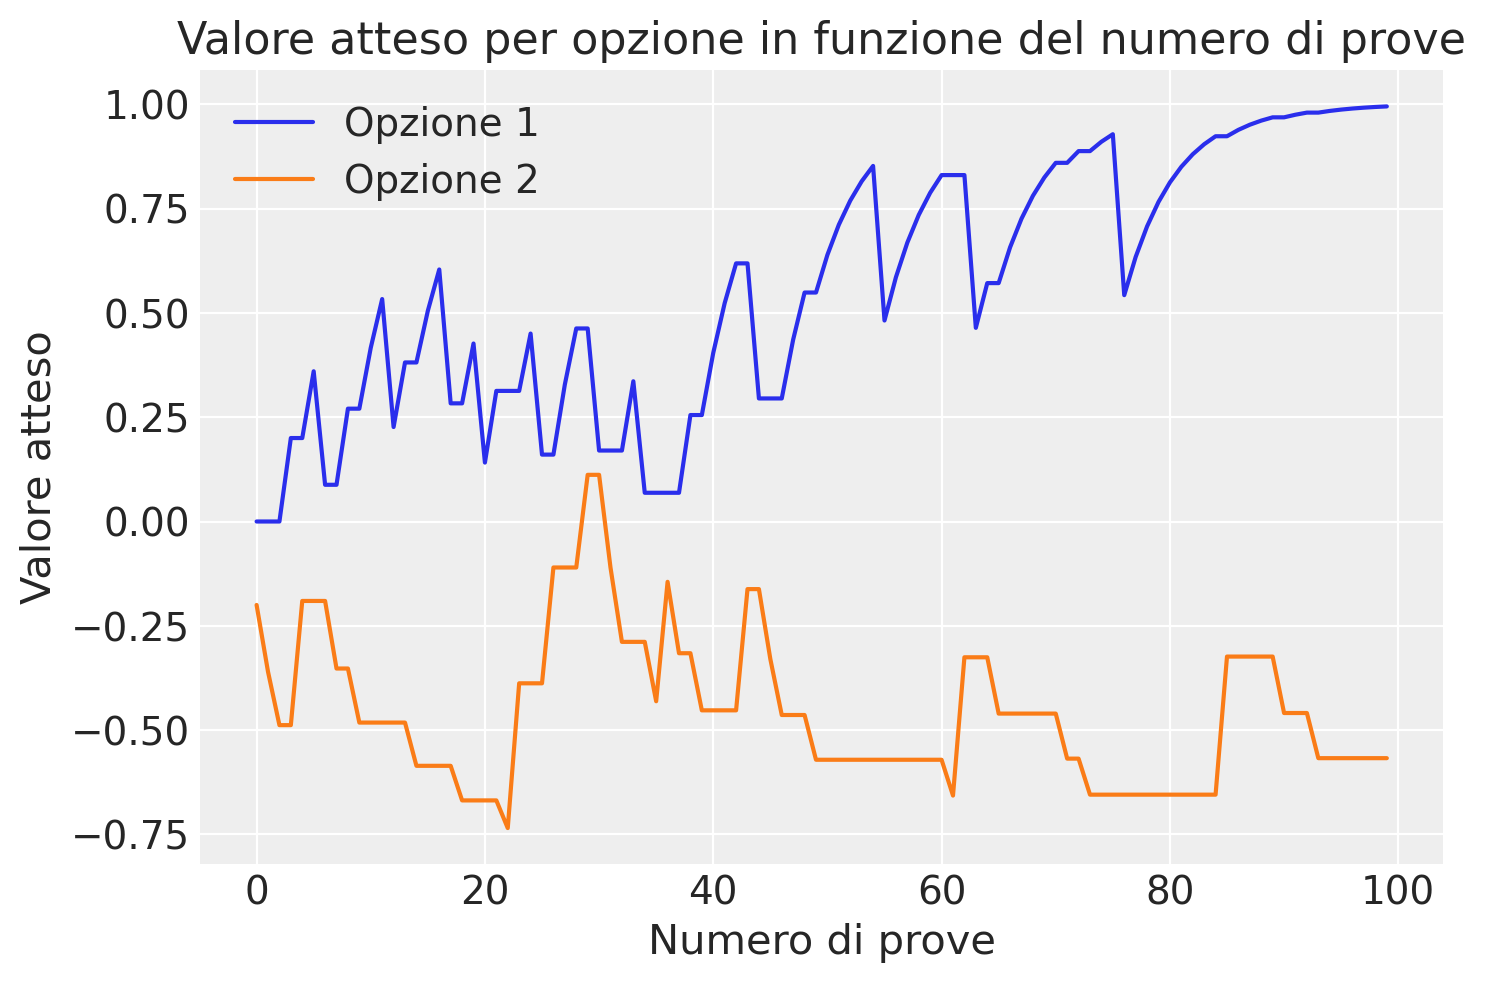

In [4]:
c = np.zeros(nt, dtype=int)
r = np.zeros(nt, dtype=float)

v = np.array([0.0, 0.0])  # Initial values for both options
v_history = np.zeros((nt, 2))  # Per tenere traccia dei valori di entrambe le opzioni ad ogni prova

for t in range(nt):
    prob_of_1 = np.exp(tau * v[0]) / (np.exp(tau * v[0]) + np.exp(tau * v[1]))
    c[t] = 1 if np.random.rand() < prob_of_1 else 2
    
    is_winner_1 = np.random.rand() < p
    if c[t] == 1:
        r[t] = 1 if is_winner_1 else -1
    else:
        r[t] = 1 if not is_winner_1 else -1
    
    pe = r[t] - v[c[t] - 1]
    v[c[t] - 1] += alpha * pe
    v_history[t] = v  # Aggiorna la cronologia dei valori

# Ora, v_history contiene i valori per entrambe le opzioni ad ogni prova
# Generiamo il grafico
plt.plot(v_history[:, 0], label='Opzione 1')
plt.plot(v_history[:, 1], label='Opzione 2')
plt.xlabel('Numero di prove')
plt.ylabel('Valore atteso')
plt.title('Valore atteso per opzione in funzione del numero di prove')
plt.legend()
plt.show()


Predisponiamo i dati per il modello Stan.

In [5]:
data = {
    "nTrials": nt,
    "choice": df["choice"].tolist(),
    "reward": df["reward"].tolist()
}

### Integrazione con Stan

Nel modello Stan, questi principi sono implementati nel blocco `model`, dove il comportamento di scelta dell'agente viene modellato attraverso la funzione `categorical_logit` che utilizza le probabilità di azione calcolate tramite la temperatura inversa e i valori di aspettativa. I parametri `lr` (tasso di apprendimento) e `tau` (temperatura inversa) sono stimati basandosi sui dati simulati.

Il modello utilizza priori per `lr` e `tau` per esprimere le conoscenze pregresse o le aspettative su questi parametri. Per esempio, `lr ~ beta(2, 2)` implica una conoscenza pregressa che il tasso di apprendimento è probabilmente distribuito uniformemente tra 0 e 1, mentre `tau ~ normal(1, 0.5)` suggerisce che ci aspettiamo che la temperatura inversa sia vicino a 1 con una certa dispersione.

In [6]:
stan_file = os.path.join('stan', 'reinforcement_learning_sp_ss_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=1> nTrials;               
  array[nTrials] int<lower=1,upper=2> choice;     
  array[nTrials] real<lower=-1, upper=1> reward; 
}

transformed data {
  vector[2] initV = rep_vector(0.0, 2);  // initial values for V
}

parameters {
  real<lower=0,upper=1> lr; // learning rate
  real<lower=0,upper=3> tau; // temperature
}

model {
  // Priors for the learning rate and temperature
  lr ~ beta(2, 2); 
  tau ~ normal(1, 0.5); // Assuming most values around 1 with some dispersion
 
  vector[2] v = initV; // Initial value for V
  real pe; // prediction error for each trial

  for (t in 1:nTrials) {
    // Compute action probabilities and model choice behavior
    choice[t] ~ categorical_logit(tau * v);

    // Calculate prediction error
    pe = reward[t] - v[choice[t]];

    // Update values based on prediction error and learning rate
    v[choice[t]] = v[choice[t]] + lr * pe;
  }
}

generated quantities {
  array[nTrials] real log_lik; // log-likelihood for each trial for

`choice[t] ~ categorical_logit(tau * v);` specifica una relazione probabilistica per la variabile "choice[t]" al tempo t. La distribuzione di "choice[t]" è modellata come una distribuzione categorica, dove le categorie sono determinate dai valori di input "tau * v". 

- "tau" rappresenta la temperatura inversa, che regola la probabilità delle scelte. Una temperatura più alta porta a una distribuzione delle probabilità più uniforme tra le categorie, mentre una temperatura più bassa enfatizza le differenze tra i valori di input.
- "v" è un vettore di valori di input che influenzano le probabilità di scelta.
- "categorical_logit" indica che le probabilità delle categorie sono calcolate utilizzando la funzione logit, che converte i valori di input in probabilità tramite la funzione softmax.

In sintesi, questo comando assegna la probabilità di "choice[t]" basata sui valori di input "tau * v", con la temperatura inversa che regola la dispersione delle probabilità tra le categorie.

Facciamo un esempio numerico. Nel 2-armed bandit task ci sono solo due categorie possibili per "choice[t]". Utilizziamo i seguenti valori:

- "tau" = 0.5
- "v" = [2, 3]

Utilizzando il comando Stan:

```stan
choice[t] ~ categorical_logit(tau * v);
```

calcoliamo le probabilità delle due categorie per "choice[t]" al tempo t:

1. Calcoliamo il prodotto tra "tau" e ciascun elemento di "v":

   tau * v = 0.5 * [2, 3] = [1, 1.5]

2. Applichiamo la funzione logit a ciascun elemento del vettore ottenuto:

   logit([1, 1.5]) = [0, 0.405]

3. Applichiamo la funzione softmax per ottenere le probabilità normalizzate:

   softmax([0, 0.405]) = [0.307, 0.693]

Quindi, le probabilità delle due categorie per "choice[t]" sono approssimativamente 30.7% per la prima categoria e 69.3% per la seconda categoria.


Consideriamo ora comando in Stan che calcola l'errore di previsione (PE - Prediction Error) per un dato momento t. 

- "reward[t]" rappresenta la ricompensa ottenuta al tempo t.
- "v[choice[t]]" indica il valore associato alla scelta effettuata al tempo t. "choice[t]" è l'indice della scelta fatta, e viene utilizzato per accedere al valore corrispondente nel vettore "v".

Quindi, l'errore di previsione viene calcolato sottraendo il valore associato alla scelta effettuata ("v[choice[t]]") dalla ricompensa ottenuta ("reward[t]"). Questo fornisce una misura di quanto la previsione del valore della scelta sia deviata dalla ricompensa effettivamente ottenuta. Un errore positivo indica che la ricompensa ottenuta è maggiore della previsione, mentre un errore negativo indica il contrario. 

Per fare un esempio numerico, supponiamo di avere i seguenti valori:

- Al tempo t, la ricompensa ottenuta è "reward[t]" = 1.
- La scelta effettuata al tempo t è indicata da "choice[t]" = 1.
- I valori associati alle scelte sono "v" = [2, 3].

Utilizzando il comando Stan:

```stan
pe = reward[t] - v[choice[t]];
```

calcoliamo l'errore di previsione:

1. Determiniamo il valore associato alla scelta effettuata al tempo t, ovvero "v[choice[t]]":

   v[choice[t]] = v[1] = 3

2. Calcoliamo l'errore di previsione sottraendo il valore associato alla scelta effettuata dalla ricompensa ottenuta:

   pe = 1 - 3 = -2

Quindi, l'errore di previsione (PE) al tempo t è -2. Questo significa che la previsione del valore della scelta è superiore di 2 rispetto alla ricompensa effettivamente ottenuta, indicando una discrepanza negativa tra la previsione e la realtà. In questo contesto, un errore di previsione negativo indica che la previsione del valore della scelta è stata troppo ottimistica rispetto alla ricompensa effettivamente ottenuta.

Infine, consideriamo l'istruzione in Stan che aggiorna il valore associato alla scelta effettuata al tempo t utilizzando l'errore di previsione (PE) moltiplicato per il tasso di apprendimento (lr): `v[choice[t]] = v[choice[t]] + lr * pe;`.

- "v[choice[t]]" rappresenta il valore associato alla scelta effettuata al tempo t.
- "lr" è il tasso di apprendimento (learning rate), che determina la velocità con cui il valore associato viene aggiornato.
- "pe" è l'errore di previsione al tempo t.

Quindi, questa istruzione calcola il nuovo valore associato alla scelta effettuata aggiungendo al valore precedente il prodotto del tasso di apprendimento per l'errore di previsione. 

Per fare un esempio numerico, supponiamo di avere i seguenti valori:

- L'errore di previsione al tempo t è "pe" = -2.
- Il tasso di apprendimento è "lr" = 0.1.
- Il valore associato alla scelta effettuata al tempo t prima dell'aggiornamento è "v[choice[t]]" = 3.

Utilizzando l'istruzione Stan:

```stan
v[choice[t]] = v[choice[t]] + lr * pe;
```

Calcoliamo il nuovo valore associato alla scelta effettuata:

1. Moltiplichiamo il tasso di apprendimento per l'errore di previsione:

   lr * pe = 0.1 * (-2) = -0.2

2. Aggiungiamo questo valore al valore associato precedente alla scelta effettuata:

   v[choice[t]] = 3 + (-0.2) = 2.8

Quindi, il nuovo valore associato alla scelta effettuata al tempo t è 2.8, dopo aver applicato l'aggiornamento basato sull'errore di previsione e il tasso di apprendimento.

Una volta definito il processo generativo dei dati, l'obiettivo è inferire i valori dei parametri del modello. Questa inferenza si basa sulle distribuzioni a priori impostate sui parametri, integrate con i dati osservati. Il blocco di codice Stan denominato `model` comprende sia le distribuzioni a priori sui parametri che la definizione della verosimiglianza, che rappresenta il processo generativo dei dati. Utilizzando queste informazioni insieme ai dati in ingresso, Stan genera campioni dalle distribuzioni a posteriori dei parametri.

Compiliamo il modello Stan.

In [7]:
model = CmdStanModel(stan_file=stan_file)
print(model)

20:20:04 - cmdstanpy - INFO - compiling stan file /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/reinforcement_learning_sp_ss_model.stan to exe file /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/reinforcement_learning_sp_ss_model
20:20:13 - cmdstanpy - INFO - compiled model executable: /Users/corradocaudek/_repositories/ds4p/chapter_4/stan/reinforcement_learning_sp_ss_model


CmdStanModel: name=reinforcement_learning_sp_ss_model
	 stan_file=/Users/corradocaudek/_repositories/ds4p/chapter_4/stan/reinforcement_learning_sp_ss_model.stan
	 exe_file=/Users/corradocaudek/_repositories/ds4p/chapter_4/stan/reinforcement_learning_sp_ss_model
	 compiler_options=stanc_options={}, cpp_options={}


Eseguiamo il campionamento.

In [8]:
fit = model.sample(
    data=data,
    iter_sampling = 4000,
    iter_warmup = 2000,
    seed = 84735,
    chains = 4
)

20:20:16 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█▌        | 00:00 Iteration:  800 / 6000 [ 13%]  (Warmup)




chain 1 |████      | 00:00 Iteration: 2200 / 6000 [ 36%]  (Sampling)

chain 1 |██████▏   | 00:00 Iteration: 3500 / 6000 [ 58%]  (Sampling)


chain 1 |███████▉  | 00:00 Iteration: 4600 / 6000 [ 76%]  (Sampling)




chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed                       
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       

20:20:16 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
print(fit.diagnose())

Processing csv files: /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp59eahp7n/reinforcement_learning_sp_ss_modelorvwiebq/reinforcement_learning_sp_ss_model-20240312202016_1.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp59eahp7n/reinforcement_learning_sp_ss_modelorvwiebq/reinforcement_learning_sp_ss_model-20240312202016_2.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp59eahp7n/reinforcement_learning_sp_ss_modelorvwiebq/reinforcement_learning_sp_ss_model-20240312202016_3.csv, /var/folders/s7/z86r4t9j6yx376cm120nln6w0000gn/T/tmp59eahp7n/reinforcement_learning_sp_ss_modelorvwiebq/reinforcement_learning_sp_ss_model-20240312202016_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Pr

Esaminiamo la distribuzione a posteriori dei parametri.

In [10]:
az.summary(fit, var_names=(["lr", "tau"]), hdi_prob=0.89)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lr,0.342,0.158,0.105,0.576,0.002,0.001,7157.0,6453.0,1.0
tau,1.343,0.231,0.965,1.691,0.003,0.002,6801.0,7191.0,1.0


Con solamente 100 prove per ciascun singolo soggetto, il modello è stato in grado di recuperare in modo accurato i valori dei parametri $\alpha$ e $\tau$ utilizzati per generare i dati forniti in input.

## Watermark

In [11]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p cmdstanpy

Last updated: Tue Mar 12 2024

Python implementation: CPython
Python version       : 3.12.2
IPython version      : 8.22.2

cmdstanpy: 1.2.1

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
pandas    : 2.2.1
seaborn   : 0.13.2
matplotlib: 3.8.3
scipy     : 1.12.0
arviz     : 0.17.0

Watermark: 2.4.3

